# Protocol resting

## Import raw data to structured JSON

Import raw resting data from `datasets/raw/resting/` to structured JSON in `datasets/resting/`.
Drop your `.txt` / `.csv` Polar export files into `cardiolab/datasets/raw/resting/` before running this cell.

In [1]:
from cardiolab.scripts.import_rr import import_all

if __name__ == "__main__":
    import_all(protocol="resting")

Skipped (already exists): 2026-04-24 07-52-36.json
Skipped (already exists): 2026-04-25 07-58-25.json


## 2. Extraction des features HRV par session

Pour chaque enregistrement, les intervalles RR sont chargés et produisent **23 indicateurs** répartis en 3 domaines :

| Domaine | Indicateurs |
|---|---|
| **Temporel** | RMSSD, ln(RMSSD), SDNN, pNN50, HR moyen |
| **Fréquentiel** | VLF, LF, HF, LF/HF, HF%, LF_nu, HF_nu, HF/FC (méthode : `welch` ou `ar`) |
| **Non-linéaire** | SD1, SD2, SD1/SD2 (Poincaré) · DFA α1 · ApEn · SampEn |

In [2]:
import glob
import json
import math

from cardiolab.protocols.resting import resting_hrv
from cardiolab.signals.rr import RRSeries

path = "cardiolab/datasets/resting/*.json"
files = sorted(glob.glob(path))

if not files:
    print("Aucun fichier JSON — déposez vos fichiers dans cardiolab/datasets/resting/")

for file in files:
    with open(file) as f:
        data = json.load(f)

    rr = RRSeries(data["rr_intervals"])
    features = resting_hrv(rr)  # retourne un HRVFeatures complet (23 champs)
    features.date = data["date"]

    print(f"\n{'═' * 54}")
    print(f"  {features.date}   ({features.duration:.0f} s enregistrés)")
    print(f"{'═' * 54}")

    print("\n  ── Domaine temporel ─────────────────────────────")
    print(f"  RMSSD      : {features.rmssd:>8.2f} ms")
    print(f"  ln(RMSSD)  : {features.ln_rmssd:>8.3f}")
    print(f"  SDNN       : {features.sdnn:>8.2f} ms")
    print(f"  pNN50      : {features.pnn50:>8.1f} %")
    print(f"  HR moyen   : {features.mean_hr:>8.1f} bpm")

    print("\n  ── Domaine fréquentiel ──────────────────────────")
    print(f"  Méthode    : {features.method}")
    print(f"  VLF        : {features.vlf:>10.2f} ms²")
    print(f"  LF         : {features.lf:>10.2f} ms²")
    print(f"  HF         : {features.hf:>10.2f} ms²")
    print(f"  LF/HF      : {features.lf_hf:>8.3f}")
    print(f"  HF%        : {features.hf_pct:>8.3f}")
    print(f"  LF_nu      : {features.lf_nu:>8.3f}")
    print(f"  HF_nu      : {features.hf_nu:>8.3f}")
    print(f"  HF/FC      : {features.hf_hr:>8.3f}  ms²/bpm")

    print("\n  ── Non-linéaire — Poincaré + DFA + Entropies ───")
    print(f"  SD1        : {features.sd1:>8.2f} ms    (variabilité court terme)")
    print(f"  SD2        : {features.sd2:>8.2f} ms    (variabilité long terme)")
    print(
        f"  SD1/SD2    : {features.sd_ratio:>8.3f}       (normal repos : 0.25 – 0.55)"
    )
    dfa_str = (
        f"{features.dfa_alpha1:.3f}"
        if not math.isnan(features.dfa_alpha1)
        else "n/a (signal trop court)"
    )
    print(f"  DFA α1     : {dfa_str:>8}       (normal repos : 0.75 – 1.25)")
    apen_str = f"{features.apen:.3f}" if not math.isnan(features.apen) else "n/a"
    sampen_str = f"{features.sampen:.3f}" if not math.isnan(features.sampen) else "n/a"
    print(f"  ApEn       : {apen_str:>8}       (normal repos : 1.2 – 1.8)")
    print(f"  SampEn     : {sampen_str:>8}       (normal repos : 1.2 – 2.0)")


══════════════════════════════════════════════════════
  2026-04-24 07-52-36   (332 s enregistrés)
══════════════════════════════════════════════════════

  ── Domaine temporel ─────────────────────────────
  RMSSD      :    78.46 ms
  ln(RMSSD)  :    4.363
  SDNN       :    95.90 ms
  pNN50      :     17.6 %
  HR moyen   :     57.9 bpm

  ── Domaine fréquentiel ──────────────────────────
  Méthode    : welch
  VLF        :    1062.05 ms²
  LF         :    1225.68 ms²
  HF         :     393.25 ms²
  LF/HF      :    3.117
  HF%        :    0.147
  LF_nu      :    0.757
  HF_nu      :    0.243
  HF/FC      :    6.792  ms²/bpm

  ── Non-linéaire — Poincaré + DFA + Entropies ───
  SD1        :    55.48 ms    (variabilité court terme)
  SD2        :   123.76 ms    (variabilité long terme)
  SD1/SD2    :    0.448       (normal repos : 0.25 – 0.55)
  DFA α1     :    0.978       (normal repos : 0.75 – 1.25)
  ApEn       :    0.961       (normal repos : 1.2 – 1.8)
  SampEn     :    1.093      

In [3]:
import glob
import json
import math

import pandas as pd
from IPython.display import display

from cardiolab.analytics.baseline import Baseline
from cardiolab.analytics.scoring import (
    readiness_score_composite,
    readiness_score_multi,
    readiness_score_nonlinear,
    readiness_score_oura,
)
from cardiolab.protocols.resting import HRVFeatures, resting_hrv
from cardiolab.signals.rr import RRSeries

# ── 1. Chargement ────────────────────────────────────────────────────


def load_features_from_json(
    path: str = "cardiolab/datasets/resting/*.json",
) -> list[HRVFeatures]:
    """Charge les fichiers JSON et retourne une liste de HRVFeatures (toutes métriques incluses)."""
    files = sorted(glob.glob(path))
    features_list = []
    for file in files:
        with open(file) as f:
            data = json.load(f)
        rr = RRSeries(data["rr_intervals"])
        features = resting_hrv(
            rr
        )  # HRVFeatures complet : pas de reconstruction manuelle
        features.date = data["date"]
        features_list.append(features)
    return features_list


# ── 2. Affichage scores ──────────────────────────────────────────────


def display_session_scores(
    features_list: list[HRVFeatures], baseline: Baseline
) -> None:
    """Affiche les métriques clés et les 4 scores pour chaque session."""
    print("═" * 58)
    print("  RÉSULTATS PAR SESSION")
    print("═" * 58)

    for f in features_list:
        s_oura = readiness_score_oura(f, baseline)
        s_multi = readiness_score_multi(f, baseline)
        s_nl = readiness_score_nonlinear(f, baseline)
        s_comp = readiness_score_composite(f, baseline)
        dfa_str = f"{f.dfa_alpha1:.3f}" if not math.isnan(f.dfa_alpha1) else "n/a"

        print(f"\n  {f.date}")
        print(f"  RMSSD  {f.rmssd:6.1f} ms  │  HR    {f.mean_hr:5.1f} bpm")
        print(
            f"  SD1    {f.sd1:6.2f} ms  │  SD2   {f.sd2:6.2f} ms  │  SD1/SD2 {f.sd_ratio:.3f}"
        )
        print(f"  DFA α1  {dfa_str}")
        print(f"  {'─' * 44}")
        print(f"  Score Oura       : {s_oura:5.1f} / 100   (RMSSD 70% + HR 30%)")
        print(
            f"  Score Multi      : {s_multi:5.1f} / 100   (RMSSD + HR + DFA α1 + tendance)"
        )
        print(
            f"  Score Non-lin.   : {s_nl:5.1f} / 100   (DFA 40% + SD1 35% + SD1/SD2 25%)"
        )
        print(f"  Score Composite  : {s_comp:5.1f} / 100  ★ (Multi 50% + Non-lin. 50%)")

    print(f"\n{'═' * 58}")
    print("  BASELINE  (fenêtre glissante 7 sessions)")
    print(f"{'═' * 58}")
    print(f"  RMSSD médian   : {baseline.median_rmssd():.2f} ms")
    print(f"  HR moyen       : {baseline.mean_hr():.2f} bpm")
    sd1_base = baseline.median_sd1()
    dfa_base = baseline.median_dfa_alpha1()
    if sd1_base:
        print(f"  SD1 médian     : {sd1_base:.2f} ms")
    if dfa_base:
        print(f"  DFA α1 médian  : {dfa_base:.3f}")


# ── Pipeline ─────────────────────────────────────────────────────────

features_list = load_features_from_json()

if not features_list:
    print("Aucune donnée trouvée dans cardiolab/datasets/resting/")
else:
    baseline = Baseline.from_features(features_list)

    # Score composite stocké dans chaque session (utilisé par le DataFrame plus bas)
    for f in features_list:
        f.score = readiness_score_composite(f, baseline)

    display_session_scores(features_list, baseline)

══════════════════════════════════════════════════════════
  RÉSULTATS PAR SESSION
══════════════════════════════════════════════════════════

  2026-04-24 07-52-36
  RMSSD    78.5 ms  │  HR     57.9 bpm
  SD1     55.48 ms  │  SD2   123.76 ms  │  SD1/SD2 0.448
  DFA α1  0.978
  ────────────────────────────────────────────
  Score Oura       :  59.4 / 100   (RMSSD 70% + HR 30%)
  Score Multi      :  61.5 / 100   (RMSSD + HR + DFA α1 + tendance)
  Score Non-lin.   :  78.2 / 100   (DFA 40% + SD1 35% + SD1/SD2 25%)
  Score Composite  :  69.8 / 100  ★ (Multi 50% + Non-lin. 50%)

  2026-04-25 07-58-25
  RMSSD    51.8 ms  │  HR     52.2 bpm
  SD1     36.62 ms  │  SD2   148.70 ms  │  SD1/SD2 0.246
  DFA α1  1.280
  ────────────────────────────────────────────
  Score Oura       :  40.6 / 100   (RMSSD 70% + HR 30%)
  Score Multi      :  57.5 / 100   (RMSSD + HR + DFA α1 + tendance)
  Score Non-lin.   :  61.4 / 100   (DFA 40% + SD1 35% + SD1/SD2 25%)
  Score Composite  :  59.4 / 100  ★ (Multi 50

### Interprétation des scores

| Score composite | Interprétation |
|---|---|
| 80 – 100 | Très bien récupéré — entraînement intensif possible |
| 60 – 80 | OK — entraînement modéré à intense |
| 40 – 60 | Fatigue modérée — privilégier la récupération |
| 20 – 40 | Fatigué — entraînement léger seulement |
| < 20 | Surcharge — repos conseillé |

### Interprétation DFA α1

| DFA α1 | Signification |
|---|---|
| 0.75 – 1.25 | Normal au repos — régulation autonome saine |
| < 0.75 | Signal de fatigue / surcompensation — vigilance |
| > 1.25 | Variabilité très structurée — rare, possible chez athlètes |

### Interprétation SD1/SD2

| SD1/SD2 | Signification |
|---|---|
| 0.25 – 0.55 | Équilibre sympatho-vagal normal au repos |
| < 0.25 | Dominance sympathique (stress, fatigue) |
| > 0.55 | Dominance parasympathique marquée |

### Interprétation ApEn (Approximate Entropy)

ApEn mesure la **régularité** du signal RR (Pincus 1991). Une valeur faible indique un signal très prévisible ; une valeur élevée reflète une bonne adaptabilité autonome.

| ApEn | Signification |
|---|---|
| < 0.5 | Très régulier — complexité très basse |
| 0.5 – 1.2 | Complexité basse |
| 1.2 – 1.8 | Plage normale au repos |
| > 1.8 | Très irrégulier — forte complexité |

### Interprétation SampEn (Sample Entropy)

SampEn est une version améliorée d'ApEn, moins sensible à la longueur du signal (Richman & Moorman 2000). Interprétation similaire à ApEn.

| SampEn | Signification |
|---|---|
| < 0.5 | Très régulier — HRV sévèrement réduite |
| 0.5 – 1.2 | Complexité réduite |
| 1.2 – 2.0 | Plage normale au repos |
| > 2.0 | Haute complexité |

> **ApEn vs SampEn** : SampEn exclut l'auto-comparaison des templates et est préféré pour les enregistrements courts. ApEn reste utile pour des séries très courtes où SampEn retourne `NaN`.

## 5. Méthode AR — analyse fréquentielle sur enregistrements courts

La méthode **AR (autorégressif, Yule-Walker)** offre une meilleure résolution spectrale sur les segments courts (< 2 min), par rapport à Welch qui requiert ≥ 256 échantillons interpolés.

| Critère | Welch (`method="welch"`) | AR (`method="ar"`) |
|---|---|---|
| Enregistrement recommandé | ≥ 5 min (standard HRV) | 1 – 3 min (transition orthostatique) |
| Résolution spectrale | Limitée sur segments courts | Excellente même sur 30 – 60 s |
| Bruit | Lissé par fenêtrage | Peut amplifier le bruit sur signal bruité |
| Référence | Task Force ESC/NASPE 1996 | Marple 1987, Burg 1975 |

> Pour le protocole orthostatique, `method="ar"` est recommandé pour analyser la fenêtre de **transition** (typiquement 20 – 60 s). Les phases allongé et debout (> 3 min) fonctionnent bien avec les deux méthodes.

In [4]:
import glob
import json
import math

from cardiolab.protocols.resting import resting_hrv
from cardiolab.signals.rr import RRSeries

# Comparaison Welch vs AR sur les mêmes enregistrements
path = "cardiolab/datasets/resting/*.json"
files = sorted(glob.glob(path))

if not files:
    print("Aucune donnée — exécutez d'abord la section Import.")
else:
    print(
        f"{'Session':<25}  {'Méthode':<8}  {'LF':>8}  {'HF':>8}  {'LF/HF':>7}  {'ApEn':>7}  {'SampEn':>8}"
    )
    print("─" * 78)
    for file in files:
        with open(file) as f:
            data = json.load(f)
        rr = RRSeries(data["rr_intervals"])
        for method in ("welch", "ar"):
            feat = resting_hrv(rr, method=method)
            apen_s = f"{feat.apen:.3f}" if not math.isnan(feat.apen) else "n/a"
            sampen_s = f"{feat.sampen:.3f}" if not math.isnan(feat.sampen) else "n/a"
            print(
                f"  {data['date']:<23}  {method:<8}  {feat.lf:>8.1f}  {feat.hf:>8.1f}"
                f"  {feat.lf_hf:>7.3f}  {apen_s:>7}  {sampen_s:>8}"
            )
    print()
    print("Note : ApEn et SampEn sont indépendants de la méthode spectrale.")

Session                    Méthode         LF        HF    LF/HF     ApEn    SampEn
──────────────────────────────────────────────────────────────────────────────
  2026-04-24 07-52-36      welch       1225.7     393.3    3.117    0.961     1.093
  2026-04-24 07-52-36      ar          2306.1    1146.5    2.011    0.961     1.093
  2026-04-25 07-58-25      welch       1465.6     496.8    2.950    1.138     1.222
  2026-04-25 07-58-25      ar          1487.5     509.9    2.917    1.138     1.222

Note : ApEn et SampEn sont indépendants de la méthode spectrale.


## 4. Vue tabulaire — historique des sessions

Toutes les sessions sous forme de `DataFrame` pandas avec mise en couleur des métriques clés.

In [5]:
# Historique complet sous forme de DataFrame pandas
# Mise en couleur : rouge = valeur basse, vert = valeur haute
if "features_list" in dir() and features_list:
    df = baseline.to_dataframe()
    cols = [
        "date",
        "rmssd",
        "sdnn",
        "mean_hr",
        "sd1",
        "sd2",
        "sd_ratio",
        "dfa_alpha1",
        "apen",
        "sampen",
        "score",
    ]
    display(
        df[cols]
        .style.format(
            {
                "rmssd": "{:.1f}",
                "sdnn": "{:.1f}",
                "mean_hr": "{:.1f}",
                "sd1": "{:.2f}",
                "sd2": "{:.2f}",
                "sd_ratio": "{:.3f}",
                "dfa_alpha1": lambda x: f"{x:.3f}" if pd.notna(x) else "n/a",
                "apen": lambda x: f"{x:.3f}" if pd.notna(x) else "n/a",
                "sampen": lambda x: f"{x:.3f}" if pd.notna(x) else "n/a",
                "score": "{:.1f}",
            }
        )
        .background_gradient(subset=["score"], cmap="RdYlGn", vmin=0, vmax=100)
        .background_gradient(subset=["rmssd"], cmap="RdYlGn")
        .background_gradient(subset=["sd1"], cmap="RdYlGn")
        .background_gradient(subset=["dfa_alpha1"], cmap="RdYlGn", vmin=0.5, vmax=1.25)
        .background_gradient(subset=["apen"], cmap="RdYlGn", vmin=0.5, vmax=1.8)
        .background_gradient(subset=["sampen"], cmap="RdYlGn", vmin=0.5, vmax=2.0)
        .background_gradient(subset=["mean_hr"], cmap="RdYlGn_r")
        .set_caption("Historique des sessions — rouge = bas · vert = élevé")
    )

,date,rmssd,sdnn,mean_hr,sd1,sd2,sd_ratio,dfa_alpha1,apen,sampen,score
0,2026-04-24 07-52-36,78.5,95.9,57.9,55.48,123.76,0.448,0.978,0.961,1.093,69.8
1,2026-04-25 07-58-25,51.8,108.3,52.2,36.62,148.70,0.246,1.280,1.138,1.222,59.4


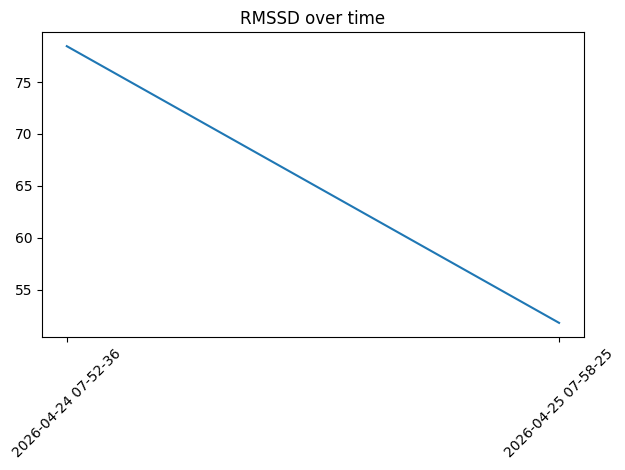

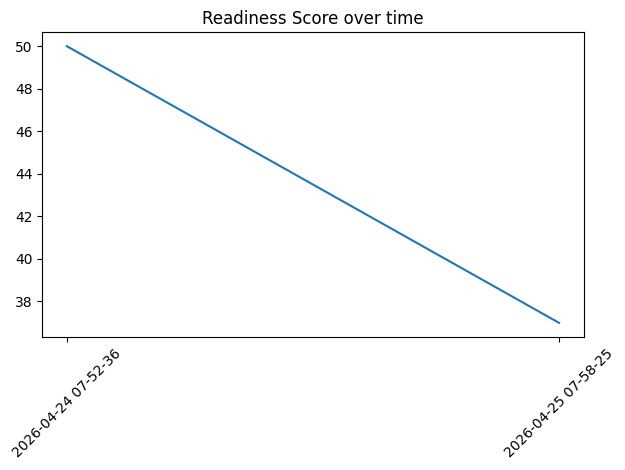

In [6]:
from cardiolab.visualization.plot import plot_resting_evolution

plot_resting_evolution(path="cardiolab/datasets/resting/*.json")

# Protocol orthostatic

## Import raw data to structured JSON

Import raw orthostatic data from `datasets/raw/orthostatic/` to structured JSON in `datasets/orthostatic/`.
The recording must contain a supine phase immediately followed by a standing phase (≥ 10 min total recommended).
Drop your `.txt` / `.csv` Polar export files into `cardiolab/datasets/raw/orthostatic/` before running this cell.

In [7]:
from cardiolab.scripts.import_rr import import_all

if __name__ == "__main__":
    import_all(protocol="orthostatic")

Skipped (already exists): 2026-05-17 09-29-27.json


## 2. Affichage rapide par session

Pour chaque fichier JSON, exécute le protocole orthostatic et affiche :
- **Phase allongé** : tous les indicateurs HRV (temporel + fréquentiel + **Poincaré + DFA α1 + ApEn + SampEn**)
- **Transition** : delta HR, HR max, durée, timestamps
- **Phase debout** : tous les indicateurs HRV (mêmes domaines)
- **Résumé** : méthode spectrale, réponse HR, variation LF/HF, variation HF%, interprétation clinique

In [8]:
import glob
import json
import math

from cardiolab.protocols.orthostatic import orthostatic_hrv
from cardiolab.signals.rr import RRSeries

path = "cardiolab/datasets/orthostatic/*.json"
files = sorted(glob.glob(path))

for file in files:
    with open(file) as f:
        data = json.load(f)

    rr = RRSeries(data["rr_intervals"])

    try:
        result = orthostatic_hrv(rr)
    except ValueError as e:
        print(f"[SKIP] {data['date']}: {e}")
        continue

    sup = result.phases.supine.features
    std = result.phases.standing.features
    tr = result.phases.transition

    def _fmt(val: float, decimals: int = 3) -> str:
        return f"{val:.{decimals}f}" if not math.isnan(val) else "n/a"

    print(f"\n{'═' * 58}")
    print(f"  {data['date']}")
    print(f"{'═' * 58}")

    print("\n  ── PHASE ALLONGÉ ────────────────────────────────")
    print(f"  Durée    : {result.phases.supine.duration_sec:.0f} s")
    print(
        f"  RMSSD    : {sup.rmssd:.2f} ms  │  SDNN  : {sup.sdnn:.2f} ms  │  pNN50 : {sup.pnn50:.1f}%"
    )
    print(f"  HR moyen : {sup.mean_hr:.1f} bpm")
    print(
        f"  HF       : {sup.hf:.2f} ms²   │  HF/FC : {sup.hf_hr:.3f}  │  LF/HF : {sup.lf_hf:.3f}"
    )
    print(f"  HF_nu    : {sup.hf_nu:.3f}       │  LF_nu : {sup.lf_nu:.3f}")
    print(
        f"  SD1      : {sup.sd1:.2f} ms  │  SD2   : {sup.sd2:.2f} ms  │  SD1/SD2: {sup.sd_ratio:.3f}"
    )
    print(f"  DFA α1   : {_fmt(sup.dfa_alpha1)}")
    print(f"  ApEn     : {_fmt(sup.apen)}   │  SampEn : {_fmt(sup.sampen)}")

    print("\n  ── TRANSITION ───────────────────────────────────")
    print(
        f"  Durée    : {tr.duration_sec:.1f} s   ({tr.start_sec:.0f}s → {tr.end_sec:.0f}s)"
    )
    print(f"  Delta HR : +{tr.delta_hr:.1f} bpm   │  HR max : {tr.peak_hr:.1f} bpm")

    print("\n  ── PHASE DEBOUT ─────────────────────────────────")
    print(f"  Durée    : {result.phases.standing.duration_sec:.0f} s")
    print(
        f"  RMSSD    : {std.rmssd:.2f} ms  │  SDNN  : {std.sdnn:.2f} ms  │  pNN50 : {std.pnn50:.1f}%"
    )
    print(f"  HR moyen : {std.mean_hr:.1f} bpm")
    print(
        f"  HF       : {std.hf:.2f} ms²   │  HF/FC : {std.hf_hr:.3f}  │  LF/HF : {std.lf_hf:.3f}"
    )
    print(f"  HF_nu    : {std.hf_nu:.3f}       │  LF_nu : {std.lf_nu:.3f}")
    print(
        f"  SD1      : {std.sd1:.2f} ms  │  SD2   : {std.sd2:.2f} ms  │  SD1/SD2: {std.sd_ratio:.3f}"
    )
    print(f"  DFA α1   : {_fmt(std.dfa_alpha1)}")
    print(f"  ApEn     : {_fmt(std.apen)}   │  SampEn : {_fmt(std.sampen)}")

    print("\n  ── RÉSUMÉ ORTHOSTATIQUE ─────────────────────────")
    print(f"  Méthode spectrale : {sup.method}")
    print(f"  Réponse HR  : +{result.hr_response:.1f} bpm")
    print(
        f"  Δ LF/HF     :  x{result.lf_hf_ratio_change:.2f}  (> 1 = activation sympathique)"
    )
    print(f"  Δ HF        :  {result.hf_response_pct:.1f}%   (normal : −30% à −50%)")
    print(f"  Δ HF/FC     :  {result.hf_hr_pct_change:.1f}%   (retrait vagal au lever)")
    print(f"  Résultat    :  {result.interpretation}")


══════════════════════════════════════════════════════════
  2026-05-17 09-29-27
══════════════════════════════════════════════════════════

  ── PHASE ALLONGÉ ────────────────────────────────
  Durée    : 308 s
  RMSSD    : 100.92 ms  │  SDNN  : 113.89 ms  │  pNN50 : 67.7%
  HR moyen : 55.7 bpm
  HF       : 2324.21 ms²   │  HF/FC : 41.737  │  LF/HF : 0.573
  HF_nu    : 0.636       │  LF_nu : 0.364
  SD1      : 71.36 ms  │  SD2   : 144.39 ms  │  SD1/SD2: 0.494
  DFA α1   : 0.705
  ApEn     : 1.182   │  SampEn : 1.894

  ── TRANSITION ───────────────────────────────────
  Durée    : 19.9 s   (308s → 328s)
  Delta HR : +116.3 bpm   │  HR max : 173.4 bpm

  ── PHASE DEBOUT ─────────────────────────────────
  Durée    : 281 s
  RMSSD    : 14.31 ms  │  SDNN  : 43.20 ms  │  pNN50 : 1.1%
  HR moyen : 81.1 bpm
  HF       : 84.29 ms²   │  HF/FC : 1.039  │  LF/HF : 4.026
  HF_nu    : 0.199       │  LF_nu : 0.801
  SD1      : 10.12 ms  │  SD2   : 60.26 ms  │  SD1/SD2: 0.168
  DFA α1   : 1.452
  

## Pipeline complet (fonctions)

In [9]:
import glob
import json
import math
from dataclasses import dataclass

from IPython.display import display

from cardiolab.protocols.orthostatic import OrthostaticResult, orthostatic_hrv
from cardiolab.signals.rr import RRSeries


@dataclass
class OrthostaticSession:
    """Conteneur pour une session orthostatique (date + résultat)."""

    date: str
    result: OrthostaticResult


def load_orthostatic_sessions(
    path: str = "cardiolab/datasets/orthostatic/*.json",
) -> list[OrthostaticSession]:
    """Charge les fichiers JSON et exécute le protocole orthostatic."""
    files = sorted(glob.glob(path))
    sessions = []
    for file in files:
        with open(file) as f:
            data = json.load(f)
        rr = RRSeries(data["rr_intervals"])
        try:
            result = orthostatic_hrv(rr)
            sessions.append(OrthostaticSession(date=data["date"], result=result))
        except ValueError as e:
            print(f"[SKIP] {data['date']}: {e}")
    return sessions


def _fmt_nan(val: float, decimals: int = 3) -> str:
    return f"{val:.{decimals}f}" if not math.isnan(val) else "n/a"


def _display_hrv_phase(label: str, features, duration_sec: float) -> None:
    """Affiche tous les indicateurs HRV d'une phase (3 domaines)."""
    dfa_str = _fmt_nan(features.dfa_alpha1)
    apen_str = _fmt_nan(features.apen)
    sampen_str = _fmt_nan(features.sampen)
    print(f"\n  {label}  (durée : {duration_sec:.0f} s)")
    print("    ── Temporel ──────────────────────────────")
    print(f"    RMSSD    : {features.rmssd:.2f} ms")
    print(f"    ln_RMSSD : {features.ln_rmssd:.3f}")
    print(f"    SDNN     : {features.sdnn:.2f} ms")
    print(f"    pNN50    : {features.pnn50:.1f} %")
    print(f"    HR moyen : {features.mean_hr:.1f} bpm")
    print("    ── Fréquentiel ───────────────────────────")
    print(f"    Méthode  : {features.method}")
    print(f"    VLF      : {features.vlf:.2f} ms²")
    print(f"    LF       : {features.lf:.2f} ms²")
    print(f"    HF       : {features.hf:.2f} ms²")
    print(f"    HF/FC    : {features.hf_hr:.3f}  ms²/bpm")
    print(f"    LF/HF    : {features.lf_hf:.3f}")
    print(f"    HF%      : {features.hf_pct:.3f}")
    print(f"    LF_nu    : {features.lf_nu:.3f}  │  HF_nu : {features.hf_nu:.3f}")
    print("    ── Non-linéaire ──────────────────────────")
    print(f"    SD1      : {features.sd1:.2f} ms  (court terme)")
    print(f"    SD2      : {features.sd2:.2f} ms  (long terme)")
    print(f"    SD1/SD2  : {features.sd_ratio:.3f}    (normal : 0.25 – 0.55)")
    print(f"    DFA α1   : {dfa_str}    (normal : 0.75 – 1.25)")
    print(f"    ApEn     : {apen_str}    (normal : 1.2 – 1.8)")
    print(f"    SampEn   : {sampen_str}    (normal : 1.2 – 2.0)")


def display_orthostatic_results(sessions: list[OrthostaticSession]) -> None:
    """Affiche les indicateurs complets des 3 phases pour chaque session."""
    for session in sessions:
        r = session.result
        p = r.phases

        print(f"\n{'═' * 58}")
        print(f"  {session.date}")
        print(f"{'═' * 58}")

        _display_hrv_phase("ALLONGÉ", p.supine.features, p.supine.duration_sec)

        print(
            f"\n  TRANSITION  (durée : {p.transition.duration_sec:.1f} s  "
            f"│  {p.transition.start_sec:.0f}s → {p.transition.end_sec:.0f}s)"
        )
        print(
            f"    Delta HR : +{p.transition.delta_hr:.1f} bpm   │  HR max : {p.transition.peak_hr:.1f} bpm"
        )

        _display_hrv_phase("DEBOUT", p.standing.features, p.standing.duration_sec)

        print(f"\n  {'─' * 46}")
        print("  RÉSUMÉ ORTHOSTATIQUE")
        print(f"  {'─' * 46}")
        print(f"  Méthode spectrale : {p.supine.features.method}")
        print(f"  Réponse HR   : +{r.hr_response:.1f} bpm")
        print(
            f"  Δ LF/HF      :  x{r.lf_hf_ratio_change:.2f}  (> 1 = activation sympathique)"
        )
        print(f"  Δ HF         :  {r.hf_response_pct:.1f}%   (normal : −30% à −50%)")
        print(f"  Δ HF/FC      :  {r.hf_hr_pct_change:.1f}%   (retrait vagal au lever)")
        print(f"  Résultat     :  {r.interpretation}")


# ── Pipeline ─────────────────────────────────────────────────────────

sessions = load_orthostatic_sessions()

if not sessions:
    print("Aucune donnée trouvée dans cardiolab/datasets/orthostatic/")
else:
    display_orthostatic_results(sessions)

    # Vue tabulaire comparative allongé vs debout
    print("\n\n" + "═" * 58)
    print("  VUE COMPARATIVE  (allongé vs debout)")
    print("═" * 58)
    rows = []
    for s in sessions:
        row = {"date": s.date}
        for col in [
            "rmssd",
            "mean_hr",
            "sd1",
            "sd2",
            "sd_ratio",
            "dfa_alpha1",
            "hf_nu",
            "apen",
            "sampen",
        ]:
            row[f"supine_{col}"] = getattr(s.result.phases.supine.features, col)
            row[f"standing_{col}"] = getattr(s.result.phases.standing.features, col)
        row["hr_response"] = s.result.hr_response
        row["hf_response_pct"] = s.result.hf_response_pct
        row["interpretation"] = s.result.interpretation
        rows.append(row)

    df_ortho = pd.DataFrame(rows)
    nan_cols = [
        c for c in df_ortho.columns if "dfa" in c or "apen" in c or "sampen" in c
    ]
    display(
        df_ortho.style.format(
            {
                c: "{:.2f}"
                for c in df_ortho.select_dtypes("float").columns
                if c not in nan_cols
            }
        )
        .format(
            {
                c: lambda x: f"{x:.3f}" if pd.notna(x) and not math.isnan(x) else "n/a"
                for c in nan_cols
            }
        )
        .background_gradient(subset=["supine_rmssd", "standing_rmssd"], cmap="RdYlGn")
        .background_gradient(subset=["hr_response"], cmap="RdYlGn_r")
        .set_caption("Comparaison allongé / debout par session")
    )


══════════════════════════════════════════════════════════
  2026-05-17 09-29-27
══════════════════════════════════════════════════════════

  ALLONGÉ  (durée : 308 s)
    ── Temporel ──────────────────────────────
    RMSSD    : 100.92 ms
    ln_RMSSD : 4.614
    SDNN     : 113.89 ms
    pNN50    : 67.7 %
    HR moyen : 55.7 bpm
    ── Fréquentiel ───────────────────────────
    Méthode  : welch
    VLF      : 503.87 ms²
    LF       : 1331.49 ms²
    HF       : 2324.21 ms²
    HF/FC    : 41.737  ms²/bpm
    LF/HF    : 0.573
    HF%      : 0.559
    LF_nu    : 0.364  │  HF_nu : 0.636
    ── Non-linéaire ──────────────────────────
    SD1      : 71.36 ms  (court terme)
    SD2      : 144.39 ms  (long terme)
    SD1/SD2  : 0.494    (normal : 0.25 – 0.55)
    DFA α1   : 0.705    (normal : 0.75 – 1.25)
    ApEn     : 1.182    (normal : 1.2 – 1.8)
    SampEn   : 1.894    (normal : 1.2 – 2.0)

  TRANSITION  (durée : 19.9 s  │  308s → 328s)
    Delta HR : +116.3 bpm   │  HR max : 173.4 bpm


,date,supine_rmssd,standing_rmssd,supine_mean_hr,standing_mean_hr,supine_sd1,standing_sd1,supine_sd2,standing_sd2,supine_sd_ratio,standing_sd_ratio,supine_dfa_alpha1,standing_dfa_alpha1,supine_hf_nu,standing_hf_nu,supine_apen,standing_apen,supine_sampen,standing_sampen,hr_response,hf_response_pct,interpretation
0,2026-05-17 09-29-27,100.922604,14.312015,55.687165,81.147742,71.363057,10.120123,144.389361,60.255331,0.494240,0.167954,0.705,1.452,0.635777,0.198967,1.182,0.849,1.894,0.795,25.460577,96.373407,normal


| Résultat | Signification |
| --- | --- |
| `normal` | Réponse orthostatique normale — hausse HR 5–30 bpm |
| `elevated_response` | Réponse excessive > 30 bpm — possible POTS |
| `impaired_response` | Réponse insuffisante < 5 bpm — possible dysautonomie |
| `excessive_vagal_withdrawal` | Retrait vagal excessif — chute HF > 60 % |

# Protocol cardiac_coherence — Cohérence cardiaque

## Import des données brutes

Déposez vos fichiers `.txt` / `.csv` Polar dans `cardiolab/datasets/raw/cardiac_coherence/` avant d'exécuter cette cellule.

Ce protocole est idéalement réalisé en **respiration cadencée 5-5** (5 s inspiration · 5 s expiration, soit ~0.1 Hz) pendant **5 minutes** en position allongée.
L'objectif est de quantifier la synchronisation entre la fréquence respiratoire et la variabilité du rythme cardiaque via l'**analyse spectrale AR**.

In [ ]:
from cardiolab.scripts.import_rr import import_all

if __name__ == "__main__":
    import_all(protocol="cardiac_coherence")

## Analyse — Cohérence cardiaque

L'algorithme calcule la **densité spectrale de puissance AR** (Yule-Walker) sur le signal RR interpolé, puis quantifie la concentration d'énergie dans la bande de résonance [0.04 – 0.26 Hz].

| Indicateur | Description | Interprétation |
|---|---|---|
| `coherence_score` | Puissance pic / puissance bande × 100 | ≥ 60 = bonne cohérence |
| `resonance_freq` | Fréquence de résonance détectée (Hz) | ~0.1 Hz = respiration cadencée 5-5 |
| `peak_power` | Puissance au pic de résonance (ms²) | Élevé = oscillation dominante marquée |
| `total_power_resonance` | Puissance totale bande [0.04–0.26 Hz] (ms²) | Dénominateur du score |
| `rmssd` | Variabilité court terme (ms) | Marqueur vagal |
| `sdnn` | Variabilité globale (ms) | Stabilité autonome globale |
| `mean_hr` | Fréquence cardiaque moyenne (bpm) | |
| `duration` | Durée de l'enregistrement (s) | ≥ 300 s recommandé |

In [ ]:
import glob
import json

import pandas as pd
from IPython.display import display

from cardiolab.protocols.cardiac_coherence import CoherenceResult, cardiac_coherence
from cardiolab.signals.rr import RRSeries


def load_coherence_sessions(
    path: str = "cardiolab/datasets/cardiac_coherence/*.json",
) -> list[CoherenceResult]:
    """Charge les fichiers JSON et exécute le protocole de cohérence cardiaque."""
    files = sorted(glob.glob(path))
    results = []
    for file in files:
        with open(file) as f:
            data = json.load(f)
        rr = RRSeries(data["rr_intervals"])
        try:
            result = cardiac_coherence(rr)
            result.date = data["date"]
            results.append(result)
        except ValueError as e:
            print(f"[SKIP] {data['date']}: {e}")
    return results


def display_coherence_results(results: list[CoherenceResult]) -> None:
    """Affiche le détail par session puis le tableau récapitulatif."""
    print("═" * 56)
    print("  RÉSULTATS PAR SESSION — Cohérence cardiaque")
    print("═" * 56)
    for r in results:
        print(f"\n  {r.date}   ({r.duration:.0f} s)")
        print(f"  Score cohérence  : {r.coherence_score:6.1f} / 100")
        print(f"  Fréquence rés.   : {r.resonance_freq:.4f} Hz")
        print(f"  Puissance pic    : {r.peak_power:10.2f} ms²")
        print(f"  Puissance bande  : {r.total_power_resonance:10.2f} ms²")
        print(f"  RMSSD / SDNN     : {r.rmssd:.2f} / {r.sdnn:.2f} ms")
        print(f"  HR moyen         : {r.mean_hr:.1f} bpm")
    print(f"\n{'═' * 56}")


def display_coherence_table(results: list[CoherenceResult]) -> None:
    """Affiche le tableau pandas coloré des résultats de cohérence cardiaque."""
    if not results:
        print("Aucune donnée.")
        return
    df = pd.DataFrame([r.to_dict() for r in results])
    display(
        df.style.format(
            {
                "coherence_score": "{:.1f}",
                "resonance_freq": "{:.4f}",
                "peak_power": "{:.2f}",
                "total_power_resonance": "{:.2f}",
                "rmssd": "{:.2f}",
                "sdnn": "{:.2f}",
                "mean_hr": "{:.1f}",
                "duration": "{:.0f}",
            }
        )
        .background_gradient(
            subset=["coherence_score"], cmap="RdYlGn", vmin=0, vmax=100
        )
        .background_gradient(subset=["rmssd"], cmap="RdYlGn")
        .background_gradient(subset=["mean_hr"], cmap="RdYlGn_r")
        .set_caption("Historique cohérence cardiaque — rouge = bas · vert = élevé")
    )


# ── Pipeline ─────────────────────────────────────────────────────────
coherence_results = load_coherence_sessions()

if not coherence_results:
    print("Aucune donnée dans cardiolab/datasets/cardiac_coherence/")
else:
    display_coherence_results(coherence_results)
    display_coherence_table(coherence_results)

### Interprétation du score de cohérence cardiaque

| Score | Niveau | Interprétation |
|---|---|---|
| ≥ 80 | Excellent | Cohérence cardiaque optimale — réponse baroréflexe maximale |
| 60 – 79 | Bonne | Cohérence cardiaque satisfaisante |
| 40 – 59 | Modérée | Cohérence partielle — technique ou récupération à améliorer |
| 20 – 39 | Faible | Faible résonance — perturbation respiratoire ou autonome |
| < 20 | Très faible | Signal non cohérent |

### Fréquence de résonance individuelle

La fréquence de résonance cardiaque varie selon les individus (typiquement 0.06 – 0.12 Hz).
Elle correspond à la fréquence respiratoire qui maximise l'amplitude du **baroréflexe** (oscillation RR la plus grande).
En respiration cadencée 5-5, la fréquence cible est ~0.1 Hz (6 cycles/min).

> **Références** : McCraty R. et al., *The Coherent Heart*, HeartMath Research Center, 2006 · Lehrer P.M. & Gevirtz R., *Heart Rate Variability Biofeedback*, Front Psychol, 5:756, 2014.

# Protocol HRR — Heart Rate Recovery

## Import des données brutes

Déposez vos fichiers `.txt` / `.csv` Polar dans `cardiolab/datasets/raw/hrr/` avant d'exécuter cette cellule.

Ce protocole analyse la **récupération post-exercice** : l'enregistrement doit commencer **immédiatement à l'arrêt de l'effort** et durer au minimum **2 minutes** (idéalement 3–5 min).
Le sujet reste en position stationnaire (assis ou debout) pendant toute la phase de récupération.

In [ ]:
from cardiolab.scripts.import_rr import import_all

if __name__ == "__main__":
    import_all(protocol="hrr")

## Analyse — Heart Rate Recovery (HRR)

La récupération de la fréquence cardiaque après l'exercice est un marqueur clinique de la **fonction vagale** et un prédicteur de mortalité cardiovasculaire (Cole et al. 1999).

| Indicateur | Formule | Signification clinique |
|---|---|---|
| `hr_peak` | FC au 1ᵉʳ intervalle | FC maximale de la séance |
| `hr_at_60s` | FC à 60 s de récupération | Récupération court terme |
| `hrr_60` | FC_pic − FC_60s | **HRR1** — marqueur vagal clé (< 12 bpm = risque accru) |
| `hr_at_120s` | FC à 120 s de récupération | Récupération moyen terme |
| `hrr_120` | FC_pic − FC_120s | **HRR2** — récupération autonome complète |
| `hrr_60_category` | Catégorie HRR1 | excellent / good / normal / impaired |
| `hrr_120_category` | Catégorie HRR2 | excellent / good / normal / impaired |
| `duration` | Durée de l'enregistrement (s) | ≥ 120 s recommandé pour HRR2 |

In [ ]:
import glob
import json
import math

import pandas as pd
from IPython.display import display

from cardiolab.protocols.hrr import HRRResult, heart_rate_recovery
from cardiolab.signals.rr import RRSeries


def load_hrr_sessions(
    path: str = "cardiolab/datasets/hrr/*.json",
) -> list[HRRResult]:
    """Charge les fichiers JSON et exécute le protocole HRR."""
    files = sorted(glob.glob(path))
    results = []
    for file in files:
        with open(file) as f:
            data = json.load(f)
        rr = RRSeries(data["rr_intervals"])
        try:
            result = heart_rate_recovery(rr)
            result.date = data["date"]
            results.append(result)
        except ValueError as e:
            print(f"[SKIP] {data['date']}: {e}")
    return results


def display_hrr_results(results: list[HRRResult]) -> None:
    """Affiche le détail par session puis le tableau récapitulatif."""
    print("═" * 56)
    print("  RÉSULTATS PAR SESSION — Heart Rate Recovery")
    print("═" * 56)
    for r in results:
        hrr120_str = (
            f"{r.hrr_120:.1f} bpm" if not math.isnan(r.hrr_120) else "n/a (< 2 min)"
        )
        hr120_str = f"{r.hr_at_120s:.1f}" if not math.isnan(r.hr_at_120s) else "n/a"
        cat120 = r.hrr_120_category if r.hrr_120_category else "n/a"
        print(f"\n  {r.date}   ({r.duration:.0f} s enregistrés)")
        print(f"  HR pic           : {r.hr_peak:.1f} bpm")
        print("  ── HRR1 (60 s) ───────────────────────────")
        print(f"  HR à 60 s        : {r.hr_at_60s:.1f} bpm")
        print(f"  HRR1             : {r.hrr_60:.1f} bpm  → {r.hrr_60_category}")
        print("  ── HRR2 (120 s) ──────────────────────────")
        print(f"  HR à 120 s       : {hr120_str}")
        print(f"  HRR2             : {hrr120_str}  → {cat120}")
    print(f"\n{'═' * 56}")


def display_hrr_table(results: list[HRRResult]) -> None:
    """Affiche le tableau pandas coloré des résultats HRR."""
    if not results:
        print("Aucune donnée.")
        return
    df = pd.DataFrame([r.to_dict() for r in results])
    display(
        df.style.format(
            {
                "hr_peak": "{:.1f}",
                "hr_at_60s": "{:.1f}",
                "hr_at_120s": lambda x: (
                    f"{x:.1f}" if pd.notna(x) and not math.isnan(float(x)) else "n/a"
                ),
                "hrr_60": "{:.1f}",
                "hrr_120": lambda x: (
                    f"{x:.1f}" if pd.notna(x) and not math.isnan(float(x)) else "n/a"
                ),
                "duration": "{:.0f}",
            }
        )
        .background_gradient(subset=["hrr_60"], cmap="RdYlGn", vmin=0, vmax=30)
        .background_gradient(subset=["hr_peak"], cmap="RdYlGn_r")
        .set_caption(
            "Historique HRR — rouge = récupération lente · vert = récupération rapide"
        )
    )


# ── Pipeline ─────────────────────────────────────────────────────────
hrr_results = load_hrr_sessions()

if not hrr_results:
    print("Aucune donnée dans cardiolab/datasets/hrr/")
else:
    display_hrr_results(hrr_results)
    display_hrr_table(hrr_results)

### Interprétation HRR1 (récupération à 60 s)

| HRR1 (bpm) | Catégorie | Signification |
|---|---|---|
| ≥ 25 | excellent | Récupération vagale optimale |
| 20 – 24 | good | Bonne récupération cardiovasculaire |
| 12 – 19 | normal | Récupération normale |
| < 12 | impaired | Récupération vagale altérée — risque cardiovasculaire accru |

### Interprétation HRR2 (récupération à 120 s)

| HRR2 (bpm) | Catégorie | Signification |
|---|---|---|
| ≥ 55 | excellent | Récupération autonome très rapide |
| 45 – 54 | good | Bonne récupération sur 2 min |
| 35 – 44 | normal | Récupération dans la norme |
| < 35 | impaired | Récupération altérée à 2 min |

> **Références** : Cole C.R. et al., *Heart Rate Recovery Immediately after Exercise as a Predictor of Mortality*, NEJM, 341(18):1351-7, 1999 · Imai K. et al., *Vagally Mediated Heart Rate Recovery after Exercise*, Circulation, 90(1):142-9, 1994.

# Protocol cardiac_drift — Dérive cardiaque

## Import des données brutes

Déposez vos fichiers `.txt` / `.csv` Polar dans `cardiolab/datasets/raw/cardiac_drift/` avant d'exécuter cette cellule.

Ce protocole détecte une **dérive progressive de la fréquence cardiaque** pendant un effort soutenu (ex. course ou cyclisme à intensité constante).
L'enregistrement doit couvrir **au minimum 3 fenêtres** de la durée sélectionnée (par défaut 60 s/fenêtre → ≥ 3 min d'effort continu).

In [ ]:
from cardiolab.scripts.import_rr import import_all

if __name__ == "__main__":
    import_all(protocol="cardiac_drift")

## Analyse — Dérive cardiaque

L'algorithme divise l'enregistrement en **fenêtres glissantes**, calcule la FC moyenne par fenêtre, puis effectue une **régression linéaire** (temps → FC) pour quantifier la pente de dérive.

| Indicateur | Description | Interprétation |
|---|---|---|
| `drift_rate` | Pente de dérive (bpm/min) | Positif = FC croissante, négatif = FC décroissante |
| `drift_magnitude` | FC_finale − FC_initiale (bpm) | Amplitude totale sur la durée de l'enregistrement |
| `r_squared` | R² de la régression linéaire | Proche de 1 = dérive linéaire nette et régulière |
| `drift_detected` | Booléen | `True` si &#124;drift_rate&#124; ≥ 0.5 bpm/min **et** R² ≥ 0.5 |
| `initial_hr` | FC 1ère fenêtre (bpm) | FC de début d'effort |
| `final_hr` | FC dernière fenêtre (bpm) | FC de fin d'effort |
| `n_windows` | Nombre de fenêtres analysées | Minimum 3 requis |
| `interpretation` | no_drift / mild / moderate / strong | Catégorie clinique |
| `duration` | Durée totale (s) | |

In [ ]:
import glob
import json

import pandas as pd
from IPython.display import display

from cardiolab.protocols.cardiac_drift import DriftResult, cardiac_drift
from cardiolab.signals.rr import RRSeries


def load_drift_sessions(
    path: str = "cardiolab/datasets/cardiac_drift/*.json",
    window_sec: float = 60.0,
) -> list[DriftResult]:
    """Charge les fichiers JSON et exécute le protocole de dérive cardiaque."""
    files = sorted(glob.glob(path))
    results = []
    for file in files:
        with open(file) as f:
            data = json.load(f)
        rr = RRSeries(data["rr_intervals"])
        try:
            result = cardiac_drift(rr, window_sec=window_sec)
            result.date = data["date"]
            results.append(result)
        except ValueError as e:
            print(f"[SKIP] {data['date']}: {e}")
    return results


def display_drift_results(results: list[DriftResult]) -> None:
    """Affiche le détail par session puis le tableau récapitulatif."""
    print("═" * 56)
    print("  RÉSULTATS PAR SESSION — Dérive cardiaque")
    print("═" * 56)
    for r in results:
        detected_str = "✓ détectée" if r.drift_detected else "✗ non détectée"
        print(f"\n  {r.date}   ({r.duration:.0f} s · {r.n_windows} fenêtres)")
        print(f"  Dérive           : {detected_str}")
        print(f"  Taux             : {r.drift_rate:+.2f} bpm/min")
        print(
            f"  Amplitude        : {r.drift_magnitude:+.1f} bpm  ({r.initial_hr:.1f} → {r.final_hr:.1f} bpm)"
        )
        print(f"  R²               : {r.r_squared:.3f}")
        print(f"  Interprétation   : {r.interpretation}")
    print(f"\n{'═' * 56}")


def display_drift_table(results: list[DriftResult]) -> None:
    """Affiche le tableau pandas coloré des résultats de dérive cardiaque."""
    if not results:
        print("Aucune donnée.")
        return
    df = pd.DataFrame([r.to_dict() for r in results])
    display(
        df.style.format(
            {
                "drift_rate": "{:+.2f}",
                "drift_magnitude": "{:+.1f}",
                "r_squared": "{:.3f}",
                "initial_hr": "{:.1f}",
                "final_hr": "{:.1f}",
                "duration": "{:.0f}",
            }
        )
        .background_gradient(subset=["drift_rate"], cmap="RdYlGn_r")
        .background_gradient(subset=["r_squared"], cmap="RdYlGn")
        .set_caption(
            "Historique dérive cardiaque — rouge = forte dérive · vert = stable"
        )
    )


# ── Pipeline ─────────────────────────────────────────────────────────
drift_results = load_drift_sessions(window_sec=60.0)

if not drift_results:
    print("Aucune donnée dans cardiolab/datasets/cardiac_drift/")
else:
    display_drift_results(drift_results)
    display_drift_table(drift_results)

### Interprétation de la dérive cardiaque

| |drift_rate| (bpm/min) | Catégorie | Signification physiologique |
|---|---|---|
| < 0.5 | no_drift | Effort stable — FC plateau atteint |
| 0.5 – 1.5 | mild | Légère dérive — glycogène ou thermorégulation |
| 1.5 – 3.0 | moderate | Dérive significative — vérifier hydratation et intensité |
| > 3.0 | strong | Dérive sévère — cardiovascular drift possible |

### Cardiovascular drift

Le *cardiovascular drift* est une augmentation progressive de la FC sans augmentation de l'intensité de l'effort, associée à :
- une **déshydratation** (↓ volume plasmatique → ↑ fréquence cardiaque)
- une **élévation thermique** (↑ débit cutané → redistribution vasculaire)
- un effort prolongé **> 45 min** à intensité sous-maximale

> **Références** : Coyle E.F. & González-Alonso J., *Heart Failure During Exercise in the Heat*, J Appl Physiol, 90(5):1702-10, 2001 · Wingo J.E. & Cureton K.J., *J Strength Cond Res*, 20(1):35-42, 2006.

# Protocol VO2max — Estimation par HRV

## Import des données brutes

Déposez vos fichiers `.txt` / `.csv` Polar dans `cardiolab/datasets/raw/vo2max/` avant d'exécuter cette cellule.

Ce protocole estime la **VO2max** à partir d'indicateurs HRV au repos. L'enregistrement doit durer **au minimum 5 minutes** en position allongée, dans des conditions de repos optimal (même heure, même contexte que la mesure HRV de référence).

> **Note** : Pour activer le modèle **Uth** (15.3 × HRmax/HRrest), renseignez votre FC max mesurée via `HR_MAX = <valeur>` dans la cellule d'analyse ci-dessous.

In [ ]:
from cardiolab.scripts.import_rr import import_all

if __name__ == "__main__":
    import_all(protocol="vo2max")

## Analyse — Estimation VO2max par HRV

Trois modèles d'estimation sont calculés en parallèle :

| Modèle | Formule | Données requises | Référence |
|---|---|---|---|
| **Uth** | 15.3 × (HRmax / HRrest) | HR max mesurée + HR repos | Uth et al. 2004 |
| **Esco-Flatt** | 18.37 + 0.054 × RMSSD | HRV au repos seulement | Esco & Flatt 2014 |
| **ln-RMSSD** | 24.89 + 5.97 × ln(RMSSD) | HRV au repos seulement | Nunan et al. 2010 |

| Indicateur | Description |
|---|---|
| `vo2max_uth` | Estimation Uth (mL/kg/min) — `nan` si HR max non fournie |
| `vo2max_esco_flatt` | Estimation Esco-Flatt (mL/kg/min) — toujours calculé |
| `vo2max_ln_rmssd` | Estimation ln-RMSSD (mL/kg/min) — toujours calculé |
| `hr_rest` | FC repos dérivée du signal RR (bpm) |
| `hr_max` | FC max fournie en entrée (bpm) — `nan` si non spécifiée |
| `rmssd_used` | RMSSD utilisé pour les estimations (ms) |
| `fitness_category` | poor / fair / good / very_good / excellent (ACSM 2022) |

In [ ]:
import glob
import json
import math

import pandas as pd
from IPython.display import display

from cardiolab.protocols.vo2max import VO2maxResult, vo2max_from_hrv
from cardiolab.signals.rr import RRSeries

# FC max optionnelle — renseignez votre valeur mesurée pour activer le modèle Uth
HR_MAX = None  # ex: HR_MAX = 185.0


def load_vo2max_sessions(
    path: str = "cardiolab/datasets/vo2max/*.json",
    hr_max: float | None = None,
) -> list[VO2maxResult]:
    """Charge les fichiers JSON et exécute le protocole VO2max."""
    files = sorted(glob.glob(path))
    results = []
    for file in files:
        with open(file) as f:
            data = json.load(f)
        rr = RRSeries(data["rr_intervals"])
        try:
            result = vo2max_from_hrv(rr, hr_max=hr_max)
            result.date = data["date"]
            results.append(result)
        except ValueError as e:
            print(f"[SKIP] {data['date']}: {e}")
    return results


def display_vo2max_results(results: list[VO2maxResult]) -> None:
    """Affiche le détail par session puis le tableau récapitulatif."""
    print("═" * 56)
    print("  RÉSULTATS PAR SESSION — Estimation VO2max")
    print("═" * 56)
    for r in results:
        uth_str = (
            f"{r.vo2max_uth:.1f} mL/kg/min"
            if not math.isnan(r.vo2max_uth)
            else "n/a (HR max requise)"
        )
        hrmax_str = (
            f"{r.hr_max:.0f} bpm" if not math.isnan(r.hr_max) else "non renseignée"
        )
        print(f"\n  {r.date}")
        print(f"  Catégorie        : {r.fitness_category}")
        print("  ── Estimations VO2max ───────────────────────")
        print(f"  Uth              : {uth_str}")
        print(f"  Esco-Flatt       : {r.vo2max_esco_flatt:.1f} mL/kg/min")
        print(f"  ln-RMSSD         : {r.vo2max_ln_rmssd:.1f} mL/kg/min")
        print("  ── Données de base ──────────────────────────")
        print(f"  HR repos         : {r.hr_rest:.1f} bpm")
        print(f"  HR max           : {hrmax_str}")
        print(f"  RMSSD            : {r.rmssd_used:.2f} ms")
        print(f"  ln(RMSSD)        : {r.ln_rmssd_used:.3f}")
    print(f"\n{'═' * 56}")


def display_vo2max_table(results: list[VO2maxResult]) -> None:
    """Affiche le tableau pandas coloré des estimations VO2max."""
    if not results:
        print("Aucune donnée.")
        return
    df = pd.DataFrame([r.to_dict() for r in results])
    nan_fmt = lambda x: (
        f"{x:.1f}" if pd.notna(x) and not math.isnan(float(x)) else "n/a"
    )  # noqa: E731
    display(
        df.style.format(
            {
                "vo2max_uth": nan_fmt,
                "vo2max_esco_flatt": "{:.1f}",
                "vo2max_ln_rmssd": "{:.1f}",
                "hr_rest": "{:.1f}",
                "hr_max": lambda x: (
                    f"{x:.0f}" if pd.notna(x) and not math.isnan(float(x)) else "n/a"
                ),
                "rmssd_used": "{:.2f}",
                "ln_rmssd_used": "{:.3f}",
            }
        )
        .background_gradient(
            subset=["vo2max_esco_flatt"], cmap="RdYlGn", vmin=28, vmax=58
        )
        .background_gradient(subset=["rmssd_used"], cmap="RdYlGn")
        .background_gradient(subset=["hr_rest"], cmap="RdYlGn_r")
        .set_caption("Historique estimations VO2max — rouge = bas · vert = élevé")
    )


# ── Pipeline ─────────────────────────────────────────────────────────
vo2max_results = load_vo2max_sessions(hr_max=HR_MAX)

if not vo2max_results:
    print("Aucune donnée dans cardiolab/datasets/vo2max/")
else:
    display_vo2max_results(vo2max_results)
    display_vo2max_table(vo2max_results)

### Catégories de condition physique (ACSM 2022)

| VO2max (mL/kg/min) | Catégorie | Signification |
|---|---|---|
| ≥ 58 | excellent | Athlète de haut niveau |
| 48 – 57 | very_good | Excellente condition physique |
| 38 – 47 | good | Bonne condition physique |
| 28 – 37 | fair | Condition physique acceptable |
| < 28 | poor | Déconditionnement physique |

### Limites des estimations HRV

- Le modèle **Uth** est le plus précis mais nécessite une FC max *mesurée* (test d'effort ou terrain).
- Les modèles **Esco-Flatt** et **ln-RMSSD** sont des estimations indirectes avec une erreur standard de ±5–7 mL/kg/min.
- Les estimations sont valides uniquement pour des enregistrements en **repos profond** (≥ 5 min, même contexte).

> **Références** : Uth N. et al., *Eur J Appl Physiol*, 91:111-5, 2004 · Esco M.R. & Flatt A.A., *J Sports Sci Med*, 13:552-7, 2014 · Nunan D. et al., *J Sports Med Phys Fitness*, 50:228-35, 2010 · ACSM's Guidelines for Exercise Testing and Prescription, 11ᵉ éd., 2022.

# Export des données

Les fonctions du module `cardiolab.io.export` permettent d'exporter vers **CSV** et **JSON** sans dépendance à pandas.

| Format | Resting | Orthostatique |
|---|---|---|
| **CSV** | Une ligne par session, 23 colonnes (dont `apen`, `sampen`, `method`) | Une ligne par test, colonnes préfixées `supine_` / `transition_` / `standing_` + `spectral_method` |
| **JSON** | Tableau de sessions | Structure imbriquée complète (phases → features) |

Les fichiers sont écrits dans `cardiolab/datasets/exports/`.

In [ ]:
from pathlib import Path

from cardiolab.io.export import (
    coherence_to_csv,
    coherence_to_json,
    drift_to_csv,
    drift_to_json,
    features_to_csv,
    features_to_json,
    hrr_to_csv,
    hrr_to_json,
    orthostatic_to_csv,
    orthostatic_to_json,
    vo2max_to_csv,
    vo2max_to_json,
)

export_dir = Path("cardiolab/datasets/exports")
export_dir.mkdir(parents=True, exist_ok=True)

# ── Resting ───────────────────────────────────────────────────────────
if "features_list" in dir() and features_list:
    path_csv = export_dir / "resting_history.csv"
    path_json = export_dir / "resting_history.json"
    features_to_csv(features_list, path_csv)
    features_to_json(features_list, path_json)
    print(f"Resting — {len(features_list)} session(s) exportée(s)")
    print(f"  CSV  → {path_csv}")
    print(f"  JSON → {path_json}")

    import pandas as pd
    from IPython.display import display

    df_check = pd.read_csv(path_csv)
    display(
        df_check[
            ["date", "rmssd", "sd1", "dfa_alpha1", "apen", "sampen", "method", "score"]
        ].head(10)
    )
else:
    print("Aucune donnée resting en mémoire — exécutez d'abord la section Resting.")

print()

# ── Orthostatique ─────────────────────────────────────────────────────
if "sessions" in dir() and sessions:
    for session in sessions:
        date_slug = session.date.replace(":", "-").replace(" ", "_")
        orthostatic_to_json(session.result, export_dir / f"ortho_{date_slug}.json")
        orthostatic_to_csv(session.result, export_dir / f"ortho_{date_slug}.csv")
        print(f"Ortho {session.date} → {export_dir}/ortho_{date_slug}.[json|csv]")
else:
    print("Aucune donnée orthostatique en mémoire.")

print()

# ── Cohérence cardiaque ───────────────────────────────────────────────
if "coherence_results" in dir() and coherence_results:
    coherence_to_csv(coherence_results, export_dir / "coherence_history.csv")
    coherence_to_json(coherence_results, export_dir / "coherence_history.json")
    print(f"Cohérence — {len(coherence_results)} session(s) exportée(s)")
    print(f"  CSV  → {export_dir}/coherence_history.csv")
    print(f"  JSON → {export_dir}/coherence_history.json")
else:
    print("Aucune donnée de cohérence en mémoire.")

print()

# ── HRR ──────────────────────────────────────────────────────────────
if "hrr_results" in dir() and hrr_results:
    hrr_to_csv(hrr_results, export_dir / "hrr_history.csv")
    hrr_to_json(hrr_results, export_dir / "hrr_history.json")
    print(f"HRR — {len(hrr_results)} session(s) exportée(s)")
    print(f"  CSV  → {export_dir}/hrr_history.csv")
    print(f"  JSON → {export_dir}/hrr_history.json")
else:
    print("Aucune donnée HRR en mémoire.")

print()

# ── Dérive cardiaque ─────────────────────────────────────────────────
if "drift_results" in dir() and drift_results:
    drift_to_csv(drift_results, export_dir / "drift_history.csv")
    drift_to_json(drift_results, export_dir / "drift_history.json")
    print(f"Dérive — {len(drift_results)} session(s) exportée(s)")
    print(f"  CSV  → {export_dir}/drift_history.csv")
    print(f"  JSON → {export_dir}/drift_history.json")
else:
    print("Aucune donnée de dérive cardiaque en mémoire.")

print()

# ── VO2max ───────────────────────────────────────────────────────────
if "vo2max_results" in dir() and vo2max_results:
    vo2max_to_csv(vo2max_results, export_dir / "vo2max_history.csv")
    vo2max_to_json(vo2max_results, export_dir / "vo2max_history.json")
    print(f"VO2max — {len(vo2max_results)} session(s) exportée(s)")
    print(f"  CSV  → {export_dir}/vo2max_history.csv")
    print(f"  JSON → {export_dir}/vo2max_history.json")
else:
    print("Aucune donnée VO2max en mémoire.")